In [ ]:
import pandas as pd


In [9]:
df = pd.read_csv("../data/listings.csv")

In [ ]:
print(df.shape)
print(df.head())

In [ ]:
df.info()

In [13]:
df[["price", "price_quote_price_per_night"]].head(10)

,price,price_quote_price_per_night
0,$42.00,42.00
1,$209.98,209.98
2,NaN,NaN
3,NaN,NaN
4,$259.09,259.09
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [18]:
df["price_num"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)

In [23]:
df["price_num"].equals(df["price_quote_price_per_night"])

True

price_num and price_quote_price_per_night columns are equal.

In [24]:
df["price_num"].describe()

count    19172.000000
mean       180.056266
std        555.620344
min          3.360000
25%         83.745000
50%        125.000000
75%        184.000000
max      36883.000000
Name: price_num, dtype: float64

count_low: 146, pct_low: 0.76%
count_high: 165, pct_high: 0.86%


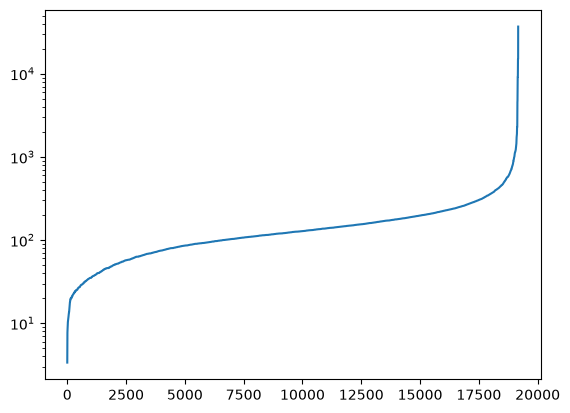

In [40]:
df["price_num"].dropna().sort_values().reset_index(drop=True).plot(logy=True)
count_low = (df["price_num"] < 20).sum()
count_high = (df["price_num"] > 1000).sum()
pct_low = 100 * count_low / df["price"].count()
pct_high = 100 * count_high / df["price"].count()
print(f"count_low: {count_low}, pct_low: {round(pct_low, 2)}%")
print(f"count_high: {count_high}, pct_high: {round(pct_high, 2)}%")

## Q1: What is the price distribution? How frequent are extreme values?

The sorted price plot (log scale, cell above) shows a distribution skewed to the right: most listings sit in a moderate range, and a small tail of very expensive listings rises quickly at the end. That tail pulls the mean up to [mean] €, above the median of [median] €, so the median describes a typical listing better than the mean.

Extreme values, over the 19,172 listings with a price:

| range       | listings | % of priced listings |
|-------------|---------:|---------------------:|
| below 20 €  |      146 |               0.76 % |
| above 1,000 € |    165 |               0.86 % |

Each group is under 1 %, and 1.6 % together. Extremes are rare, but large enough to distort the mean.

In [46]:
NaN_prices = df["price"].isna().sum()
pct_NaN_prices = NaN_prices / len(df) * 100
print(f"NaN_prices: {NaN_prices}")
print(f"pct_NaN_prices: {round(pct_NaN_prices, 2)}%")

df["price_missing"] = df["price_num"].isna()
print(df.groupby("source")["price_missing"].size())
print(df.groupby("source")["price_missing"].mean())

NaN_prices: 3536
pct_NaN_prices: 15.57%
source
city scrape        18548
previous scrape     4160
Name: price_missing, dtype: int64
source
city scrape        0.015366
previous scrape    0.781490
Name: price_missing, dtype: float64


## Q2: How many prices are missing? Where do they come from?

3,536 of the 22,708 listings (15.57 %) have no price.

| source          | listings | missing price | % missing |
|-----------------|---------:|--------------:|----------:|
| city scrape     |   18,548 |           285 |     1.5 % |
| previous scrape |    4,160 |         3,251 |    78.1 % |

The missing prices are not random: 92 % of them (3,251 of 3,536) come from listings marked as "previous scrape", which were seen in an earlier scrape but not found in this one. These are most likely listings that are no longer active, so they have no current price. Candidate decision for T2 (cleaning): drop the "previous scrape" listings and justify it with these numbers.